In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def process_task_data(df, task):
    task_data = df[df['task'] == task]
    print(f"{task.capitalize()} data shape:", task_data.shape)
    return task_data

def create_plots(task_data, task, metric, save = False):
    metric_data = task_data[task_data['metric'] == metric]
    metric_data['value'] = metric_data['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    print(f"Data for {metric}:")
    print(metric_data.head(3))

    if metric_data.empty:
        print(f"Warning: No data found for metric '{metric}'")
        axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=12, fontweight='bold')

    # Create a new row for each config value
    unique_configs = metric_data['config'].unique()
    num_configs = len(unique_configs)
    fig.set_figheight(6 * num_configs)  # Adjust figure height based on number of configs

    for j, config in enumerate(unique_configs):
        config_data = metric_data[metric_data['config'] == config]
        ax = plt.subplot(num_configs, len(metrics), i + 1 + j * len(metrics))
        
        sns.barplot(data=config_data, x='finetune_algo', y='value', hue='type', ax=ax, order=['n/a', 'lora', 'full'])
        ax.set_title(f'{metric} - {config}')
        ax.set_xlabel('Finetune Algorithm')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)


        
        if i == len(metrics) - 1:  # Only add legend to the last subplot in each row
            ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.legend().remove()

    
    

In [4]:
import os 
df = pd.read_csv('combined_metrics.csv')

# df = df[df['change'] == change]

# print("DataFrame shape:", df.shape)
# print("DataFrame columns:", df.columns)
# print("Unique values in 'Task' column:", df['task'].unique())
# print("Unique values in 'Metric' column:", df['metric'].unique())

# tasks = ['celebrity', 'art', 'object']

# plt.style.use('fivethirtyeight')


# for task in tasks:
#     task_data = process_task_data(df, task)
    
#     if task_data.empty:
#         print(f"Error: No data found for the '{task}' task.")
#         continue
#     create_plots(task_data, task)

# import os
# import shutil

# def delete_checkpoints(root_dir):
#     for dirpath, dirnames, filenames in os.walk(root_dir):
#         for dirname in dirnames:
#             if dirname.startswith('checkpoint-'):
#                 try:
#                     checkpoint_num = int(dirname.split('-')[1])
#                     if 100 <= checkpoint_num <= 1000:
#                         full_path = os.path.join(dirpath, dirname)
#                         print(f"Deleting: {full_path}")
#                         shutil.rmtree(full_path)
#                 except ValueError:
#                     # If the checkpoint number can't be converted to int, skip it
#                     continue

# # Path to the MACE experiments
# mace_experiments_path = '/data/healthy-ml/scratch/ralur/projects/MACE-Update/experiments/MACE/'

# # Call the function to delete checkpoints
# delete_checkpoints(mace_experiments_path)

# print("Checkpoint deletion complete.")


The following groups have an incorrect number of values:
Group ('erase_ship', 'before fine-tuning') has 4 values:
     algo    change    task      config finetune_algo finetune_task  \
82   MACE  baseline  object  erase_ship          none          none   
103  MACE  baseline  object  erase_ship          none          none   
124  MACE  baseline  object  erase_ship          none          none   
127  MACE  baseline  object  erase_ship          none          none   

    finetune_prompts           prompts_csv  seed    type    metric  value  \
82              none  object_ship_concepts     1  erased  clip_acc  0.105   
103             none  object_ship_concepts     2  erased  clip_acc  0.105   
124             none  object_ship_concepts     0  erased  clip_acc  0.060   
127             none  object_ship_concepts     0  erased  clip_acc  0.065   

                  phase  
82   before fine-tuning  
103  before fine-tuning  
124  before fine-tuning  
127  before fine-tuning  


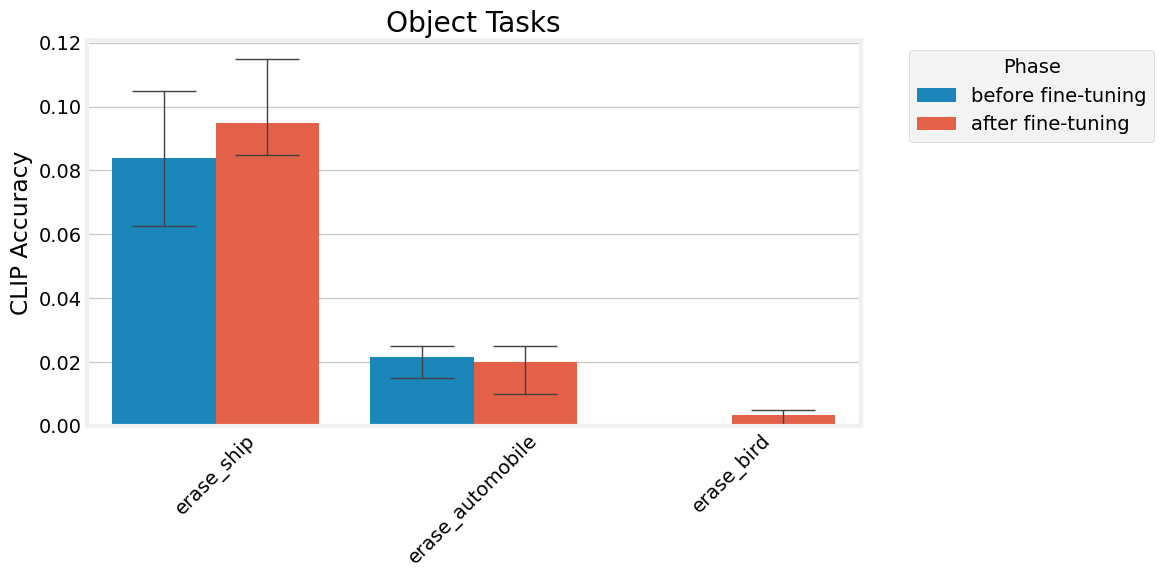

Figure saved as 'figures/warmup/object_warmup_impact.png'


/tmp/ipykernel_4031762/4206472737.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Phase', bbox_to_anchor=(1.05, 1), loc='upper left')


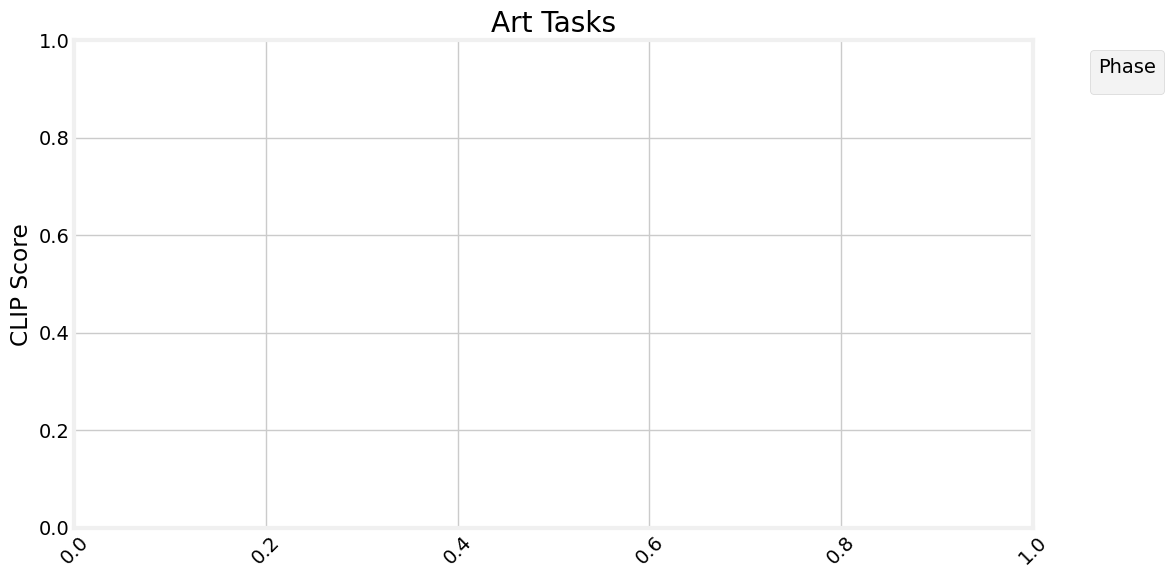

Figure saved as 'figures/warmup/art_warmup_impact.png'
The following groups have an incorrect number of values:
Group ('erase_cele_1', 'before fine-tuning') has 4 values:
     algo    change       task        config finetune_algo finetune_task  \
148  MACE  baseline  celebrity  erase_cele_1          none          none   
151  MACE  baseline  celebrity  erase_cele_1          none          none   
155  MACE  baseline  celebrity  erase_cele_1          none          none   
156  MACE  baseline  celebrity  erase_cele_1          none          none   

    finetune_prompts           prompts_csv  seed    type metric  value  \
148             none  celebrity_1_concepts     1  erased    GCD    0.0   
151             none  celebrity_1_concepts     2  erased    GCD    0.0   
155             none  celebrity_1_concepts     0  erased    GCD    0.0   
156             none  celebrity_1_concepts     0  erased    GCD    0.0   

                  phase  
148  before fine-tuning  
151  before fine-tuning  

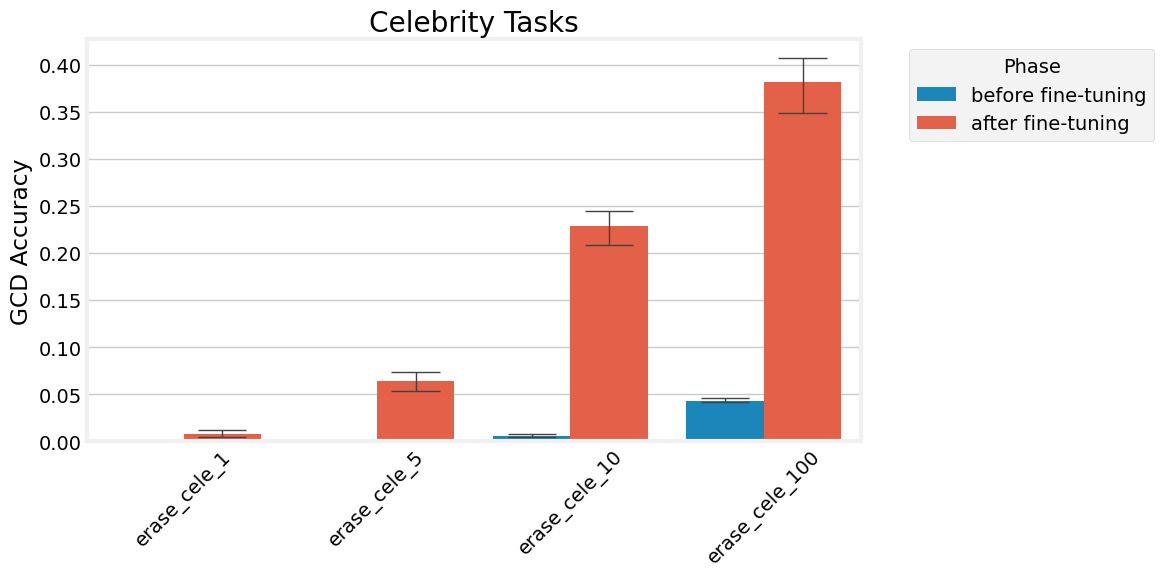

Figure saved as 'figures/warmup/celebrity_warmup_impact.png'


In [31]:
change = 'warmup'
change_str = 'baseline'
metric_map = {'object': 'clip_acc', 'art': 'clip_score', 'celebrity': 'GCD'}
metric_str = {'clip_acc': 'CLIP Accuracy', 'clip_score': 'CLIP Score', 'GCD': 'GCD Accuracy'}
    
for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
        
    #df_fig = df_fig[df_fig['finetune_task'] == task]
    #df_fig = df_fig[df_fig['type'] != 'others']
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))

    # Filter out 'full' type and keep only 'none' and 'lora'
    df_fig = df_fig[df_fig['finetune_algo'].isin(['none', 'lora'])]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]

    df_fig = df_fig[df_fig['type'].isin(['erased'])]
    if task == 'celebrity':
        df_fig['config_num'] = df_fig['config'].str.extract('(\d+)$').astype(int)
        df_fig = df_fig.sort_values('config_num')
        custom_order = df_fig['config'].unique()
        df_fig = df_fig.drop('config_num', axis=1)


    # Create a new 'phase' column based on 'finetune_algo'
    df_fig['phase'] = df_fig['finetune_algo'].map({'none': 'before fine-tuning', 'lora': 'after fine-tuning'})

    # Create a single figure
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')  # Set figure background to white
    ax.set_facecolor('white')  # Set axes background to white

    grouped = df_fig.groupby(['config', 'phase'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)
        
        # Raise an exception to halt execution
        #raise ValueError("Some groups have an incorrect number of values. Please check the data and try again.")
            
    sns.barplot(data=df_fig, x='config', y='value', hue='phase', ax=ax, order=df_fig['config'].unique(), capsize=0.5, err_kws={'linewidth': 1})

    ax.set_title(f'{task.capitalize()} Tasks')
    ax.set_xlabel('')
    #ax.set_xlabel('Task')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=45)

    ax.legend(title='Phase', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    os.makedirs('figures/warmup', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/warmup/{task}_warmup_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Figure saved as 'figures/warmup/{task}_warmup_impact.png'")


Data for clip_acc:
   algo       change    task      config finetune_algo finetune_task  \
0  MACE  car_reg=0.0  object  erase_ship          lora        object   
1  MACE  car_reg=0.0  object  erase_ship          lora        object   
2  MACE  car_reg=0.0  object  erase_ship          lora        object   

               finetune_prompts           prompts_csv  seed      type  \
0  object_random_concepts_seed0  object_ship_concepts     0    erased   
1  object_random_concepts_seed0  object_ship_concepts     0    others   
2  object_random_concepts_seed0  object_ship_concepts     0  synonyms   

     metric     value  
0  clip_acc  0.085000  
1  clip_acc  0.999444  
2  clip_acc  0.153333  
(54, 12)
The following groups have an incorrect number of values:
Group ('car_reg=0.1', 'erased') has 2 values:
     algo       change    task      config finetune_algo finetune_task  \
270  MACE  car_reg=0.1  object  erase_ship          lora        object   
267  MACE  car_reg=0.1  object  erase_ship 

/tmp/ipykernel_4031762/2668460637.py:47: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)


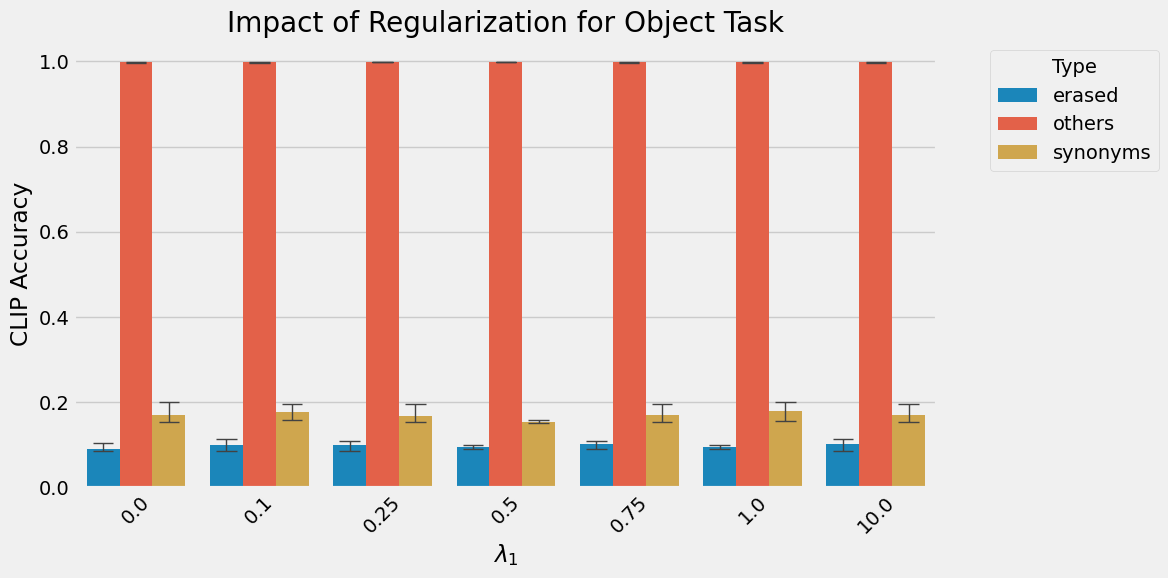

Figure saved as 'figures/regularization/object_regularization_impact.png'
Data for clip_score:
    algo       change task         config finetune_algo finetune_task  \
9   MACE  car_reg=0.0  art  erase_art_100          lora           art   
10  MACE  car_reg=0.0  art  erase_art_100          lora           art   
11  MACE  car_reg=0.0  art  erase_art_100          lora           art   

             finetune_prompts       prompts_csv  seed type      metric  \
9   art_random_concepts_seed0  art_100_concepts     0    0  clip_score   
10  art_random_concepts_seed0  art_100_concepts     0    1  clip_score   
11  art_random_concepts_seed0  art_100_concepts     0    0  clip_score   

      value  
9   21.6014  
10  21.3225  
11  21.6014  
(84, 12)
The following groups have an incorrect number of values:
Group ('car_reg=0.0', '0') has 6 values:
    algo       change task         config finetune_algo finetune_task  \
9   MACE  car_reg=0.0  art  erase_art_100          lora           art   
11  MA

/tmp/ipykernel_4031762/2668460637.py:47: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)


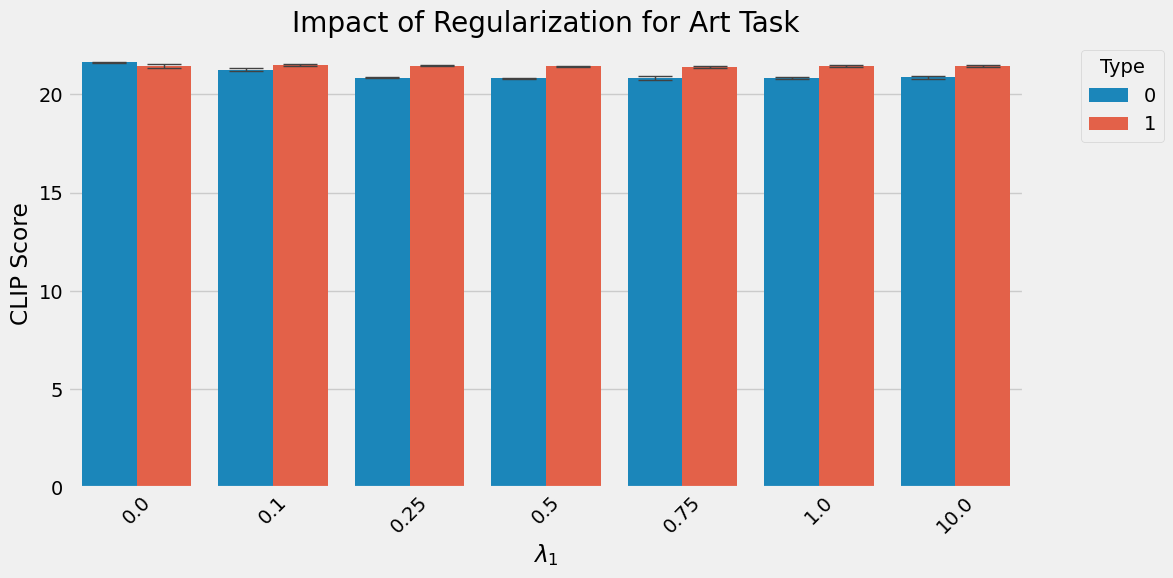

Figure saved as 'figures/regularization/art_regularization_impact.png'
Data for GCD:
    algo       change       task         config finetune_algo finetune_task  \
21  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
22  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
23  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   

                   finetune_prompts            prompts_csv  seed    type  \
21  celebrity_random_concepts_seed0  celebrity_10_concepts     1  erased   
22  celebrity_random_concepts_seed0  celebrity_10_concepts     1  others   
23  celebrity_random_concepts_seed0  celebrity_10_concepts     2  erased   

   metric     value  
21    GCD  0.124000  
22    GCD  0.934729  
23    GCD  0.140562  
(63, 12)
The following groups have an incorrect number of values:
Group ('car_reg=0.0', 'erased') has 5 values:
    algo       change       task         config finetune_algo finetune_task  \
21  MACE  car_

/tmp/ipykernel_4031762/2668460637.py:47: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)


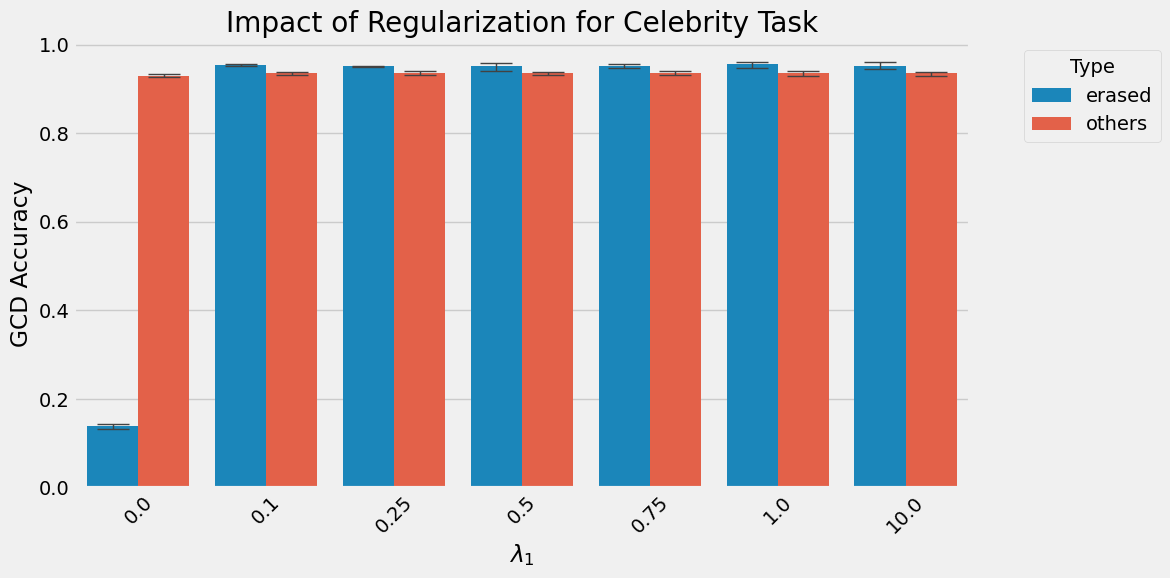

Figure saved as 'figures/regularization/celebrity_regularization_impact.png'


In [32]:
change = 'regularization'
change_str = 'car_reg'
task = 'object'

    
for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]


    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    #df_fig = df_fig[df_fig['type'] != 'others']
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    print(f"Data for {metric}:")
    print(df_fig.head(3))
    print(df_fig.shape)

    # Filter out 'full' type and keep only 'n/a' and 'lora'
    df_fig = df_fig[df_fig['finetune_algo'].isin(['n/a', 'lora'])]

    # Extract the numeric value from 'change' column and sort
    df_fig['change_value'] = df_fig['change'].str.extract('(\d+(?:\.\d+)?)').astype(float)
    df_fig = df_fig.sort_values('change_value')

    # Create a single figure
    fig, ax = plt.subplots(figsize=(12, 6))
    #fig.suptitle(f'{task.capitalize()} Task', fontsize=16)

    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    # Plot the data with sorted x-axis and smaller confidence interval bars
    sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)

    ax.set_title(f'Impact of Regularization for {task.capitalize()} Task')
    ax.set_xlabel(r'$\lambda_1$')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=45)

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/regularization' directory if it doesn't exist
    import os
    os.makedirs('figures/regularization', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/regularization/{task}_regularization_impact.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/regularization/{task}_regularization_impact.png'")


The following groups have an incorrect number of values:
Group ('lora', 'erased') has 9 values:
     algo    change    task            config finetune_algo finetune_task  \
94   MACE  baseline  object        erase_ship          lora        object   
109  MACE  baseline  object        erase_ship          lora        object   
136  MACE  baseline  object        erase_ship          lora        object   
288  MACE  baseline  object  erase_automobile          lora        object   
294  MACE  baseline  object  erase_automobile          lora        object   
300  MACE  baseline  object  erase_automobile          lora        object   
403  MACE  baseline  object        erase_bird          lora        object   
409  MACE  baseline  object        erase_bird          lora        object   
415  MACE  baseline  object        erase_bird          lora        object   

                 finetune_prompts                 prompts_csv  seed    type  \
94   object_random_concepts_seed0        object_ship_c

/tmp/ipykernel_4031762/4076582775.py:38: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


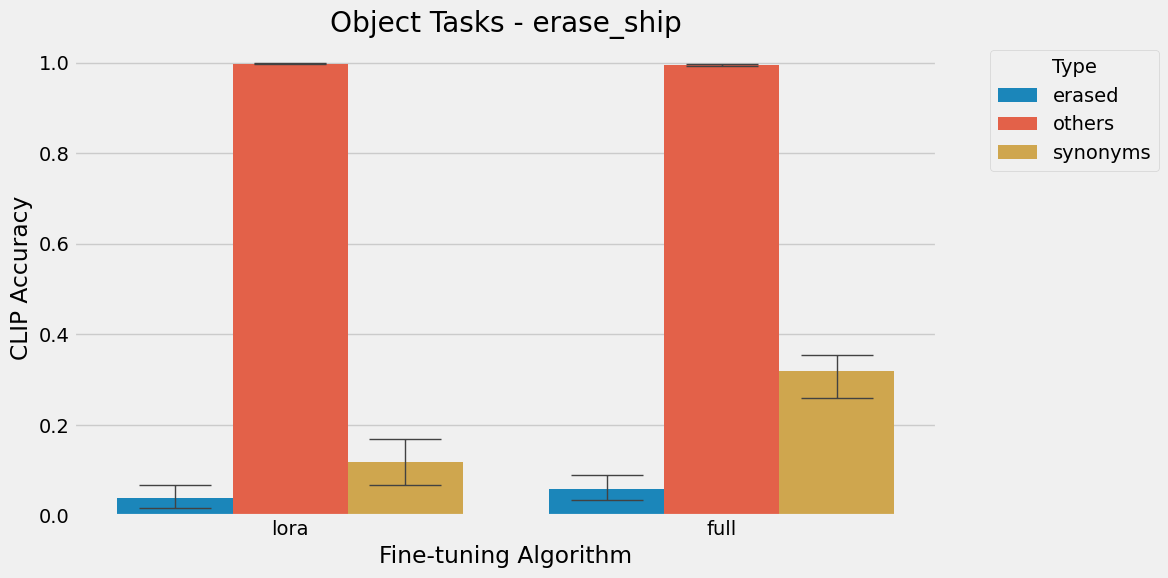

Figure saved as 'figures/finetuning/object_finetuning_comparison.png'
The following groups have an incorrect number of values:
Group ('lora', '0') has 4 values:
    algo    change task         config finetune_algo finetune_task  \
44  MACE  baseline  art  erase_art_100          lora           art   
58  MACE  baseline  art  erase_art_100          lora           art   
68  MACE  baseline  art  erase_art_100          lora           art   
70  MACE  baseline  art  erase_art_100          lora           art   

             finetune_prompts       prompts_csv  seed type      metric  \
44  art_random_concepts_seed0  art_100_concepts     1    0  clip_score   
58  art_random_concepts_seed0  art_100_concepts     2    0  clip_score   
68  art_random_concepts_seed0  art_100_concepts     0    0  clip_score   
70  art_random_concepts_seed0  art_100_concepts     0    0  clip_score   

      value  
44  21.6982  
58  21.6903  
68  21.4977  
70  21.4977  
Group ('lora', '1') has 4 values:
    algo    c

/tmp/ipykernel_4031762/4076582775.py:38: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


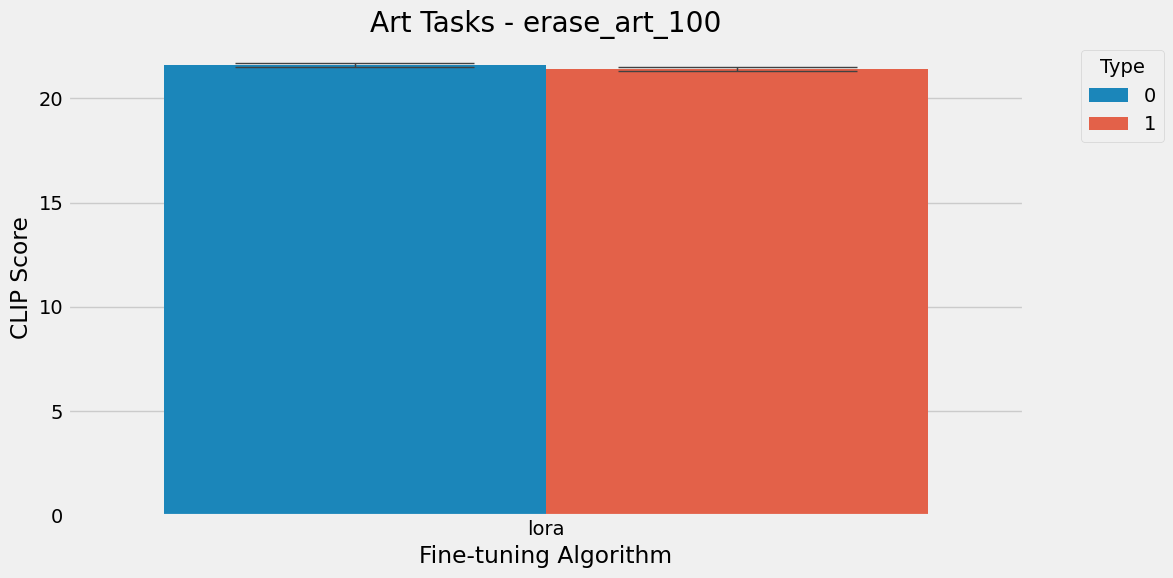

Figure saved as 'figures/finetuning/art_finetuning_comparison.png'
The following groups have an incorrect number of values:
Group ('full', 'others') has 2 values:
     algo    change       task         config finetune_algo finetune_task  \
198  MACE  baseline  celebrity  erase_cele_10          full     celebrity   
234  MACE  baseline  celebrity  erase_cele_10          full     celebrity   

                    finetune_prompts            prompts_csv  seed    type  \
198  celebrity_random_concepts_seed0  celebrity_10_concepts     1  others   
234  celebrity_random_concepts_seed0  celebrity_10_concepts     0  others   

    metric     value  
198    GCD  0.878433  
234    GCD  0.876473  
Group ('lora', 'erased') has 14 values:
     algo    change       task          config finetune_algo finetune_task  \
150  MACE  baseline  celebrity    erase_cele_1          lora     celebrity   
153  MACE  baseline  celebrity    erase_cele_1          lora     celebrity   
158  MACE  baseline  celebrity

/tmp/ipykernel_4031762/4076582775.py:38: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


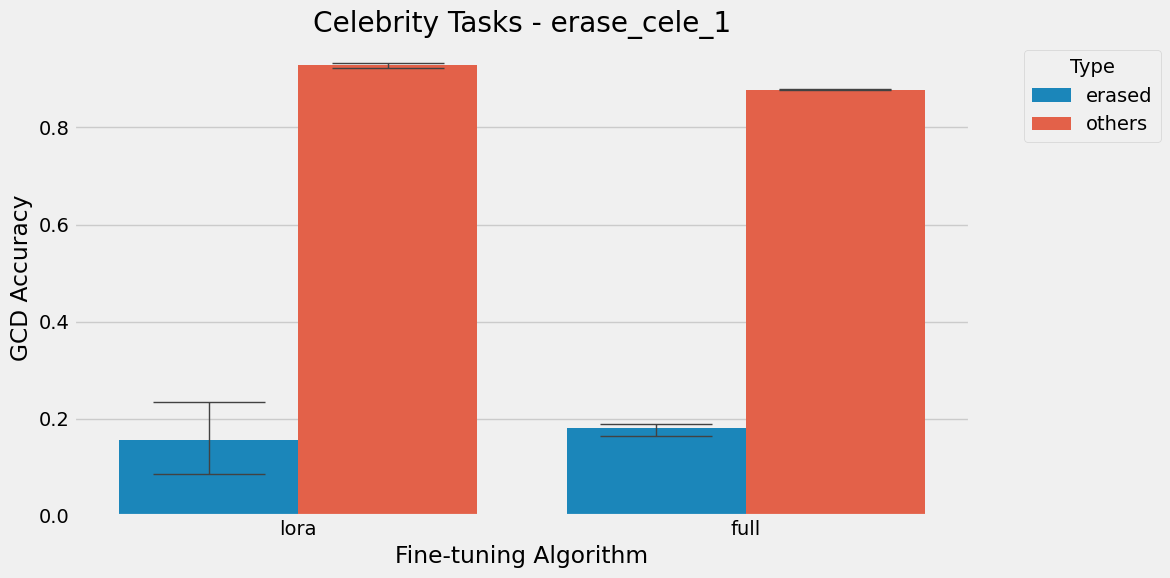

Figure saved as 'figures/finetuning/celebrity_finetuning_comparison.png'


In [38]:
change = 'finetuning'
change_str = 'baseline'

for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))

    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['full', 'lora'])]
    #df_fig = df_fig[df_fig['config'] == 'erase_ship']

    # Include both 'erased' and 'others' types
    #df_fig = df_fig[df_fig['type'].isin(['erased', 'others'])]

    grouped = df_fig.groupby(['finetune_algo', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    # Create a single figure
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
    ax.set_xlabel('Fine-tuning Algorithm')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/warmup' directory if it doesn't exist
    import os
    os.makedirs('figures/finetuning', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/finetuning/{task}_finetuning_comparison.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/finetuning/{task}_finetuning_comparison.png'")


/tmp/ipykernel_4031762/2050490010.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['prompt_number'].unique())
/tmp/ipykernel_4031762/2050490010.py:43: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


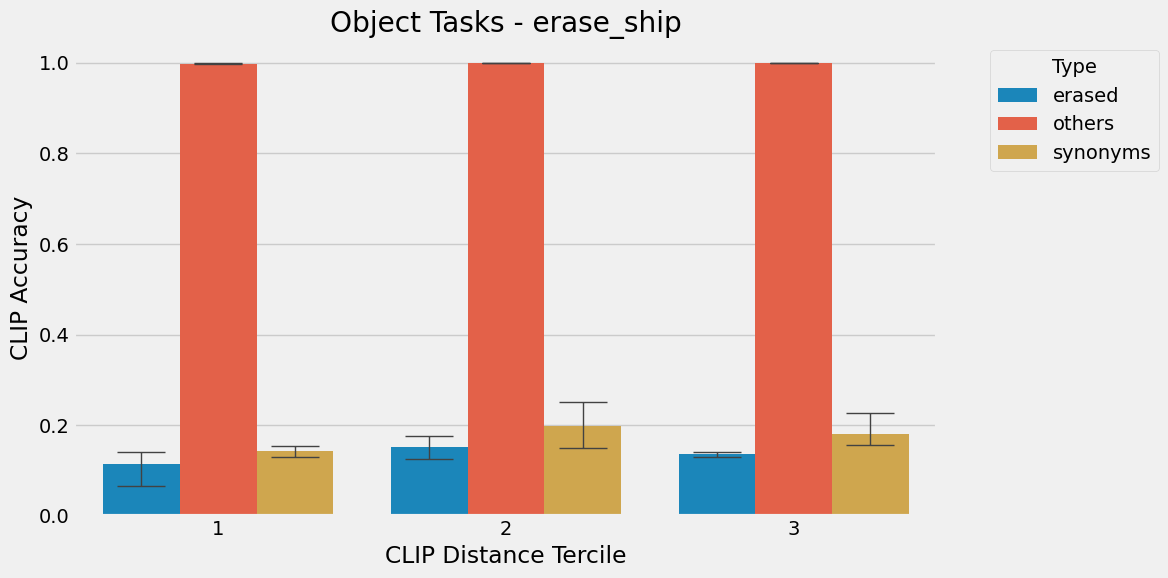

Figure saved as 'figures/clip_distance/object_clip_distance.png'


/tmp/ipykernel_4031762/2050490010.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['prompt_number'].unique())
/tmp/ipykernel_4031762/2050490010.py:43: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


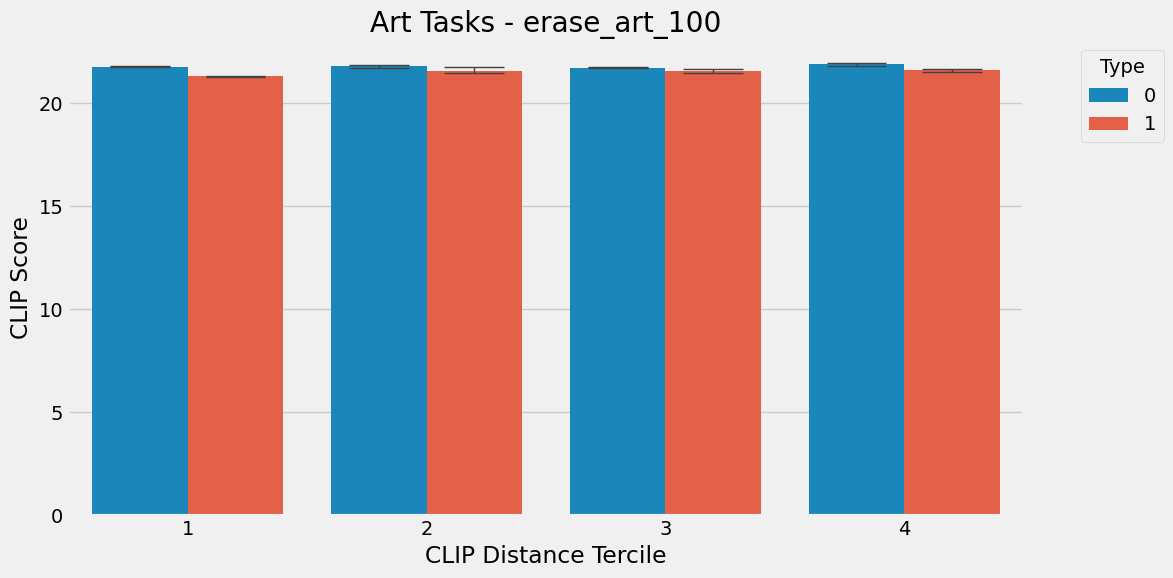

Figure saved as 'figures/clip_distance/art_clip_distance.png'


/tmp/ipykernel_4031762/2050490010.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['prompt_number'].unique())
/tmp/ipykernel_4031762/2050490010.py:43: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


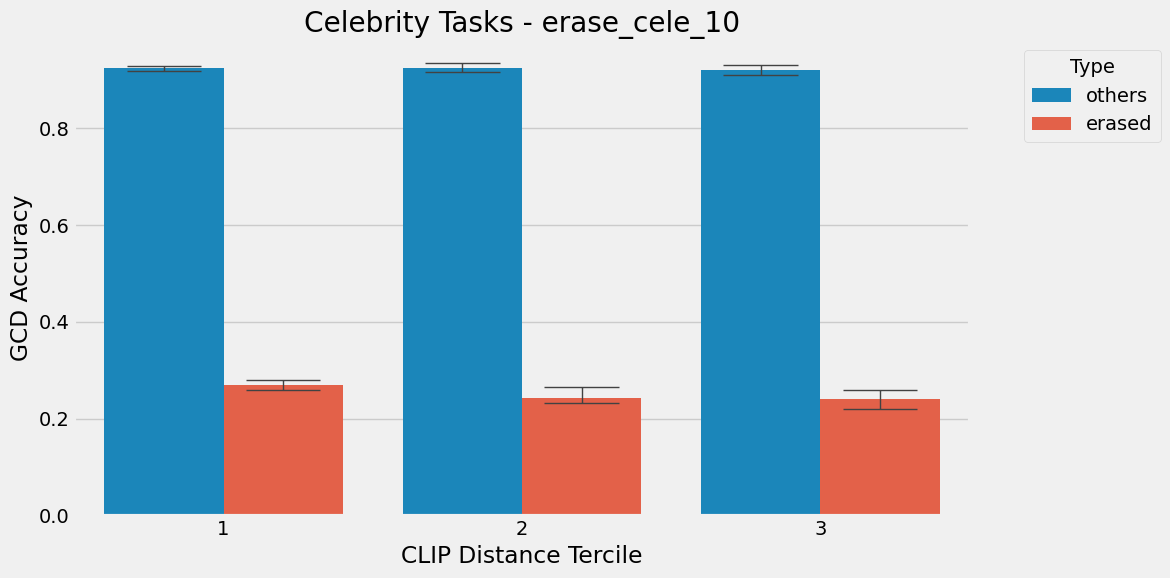

Figure saved as 'figures/clip_distance/celebrity_clip_distance.png'


In [50]:
change = 'CLIP Distance'
change_str = 'baseline'

for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("clip_", na=False)]
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    
    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]

    grouped = df_fig.groupby(['finetune_prompts', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)


    fig, ax = plt.subplots(figsize=(12, 6))

    # Sort the DataFrame based on the number at the end of finetune_prompts
    df_fig['prompt_number'] = df_fig['finetune_prompts'].str.extract('(\d+)$').astype(int)
    df_fig['prompt_number'] = df_fig['prompt_number'] + 1
    df_fig = df_fig.sort_values('prompt_number')
    
    custom_order = df_fig['finetune_prompts'].unique()
    ax.set_xlabel('CLIP Distance Tercile')
    ax.set_xticklabels(df_fig['prompt_number'].unique())

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/warmup' directory if it doesn't exist
    import os
    os.makedirs('figures/clip_distance', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/clip_distance/{task}_clip_distance.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/clip_distance/{task}_clip_distance.png'")

/tmp/ipykernel_4031762/4022092061.py:36: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_4031762/4022092061.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['finetune_task'].unique())


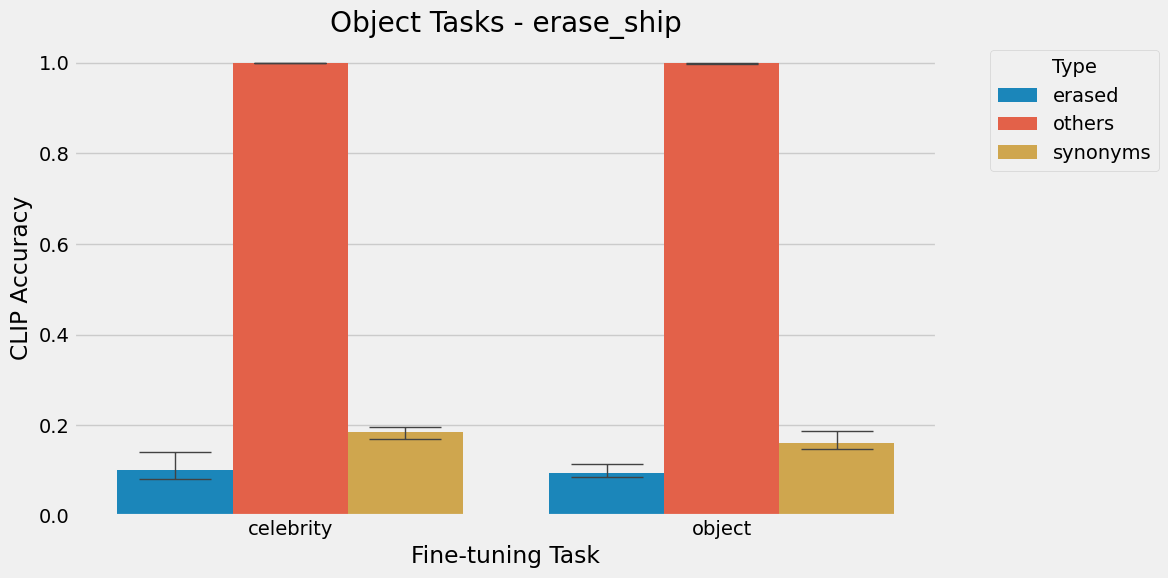

Figure saved as 'figures/in_vs_out_domain/object_in_vs_out_domain.png'
The following groups have an incorrect number of values:
Group ('art', '0') has 4 values:
    algo    change task         config finetune_algo finetune_task  \
44  MACE  baseline  art  erase_art_100          lora           art   
58  MACE  baseline  art  erase_art_100          lora           art   
68  MACE  baseline  art  erase_art_100          lora           art   
70  MACE  baseline  art  erase_art_100          lora           art   

             finetune_prompts       prompts_csv  seed type      metric  \
44  art_random_concepts_seed0  art_100_concepts     1    0  clip_score   
58  art_random_concepts_seed0  art_100_concepts     2    0  clip_score   
68  art_random_concepts_seed0  art_100_concepts     0    0  clip_score   
70  art_random_concepts_seed0  art_100_concepts     0    0  clip_score   

      value  
44  21.6982  
58  21.6903  
68  21.4977  
70  21.4977  
Group ('art', '1') has 4 values:
    algo    ch

/tmp/ipykernel_4031762/4022092061.py:36: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_4031762/4022092061.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['finetune_task'].unique())


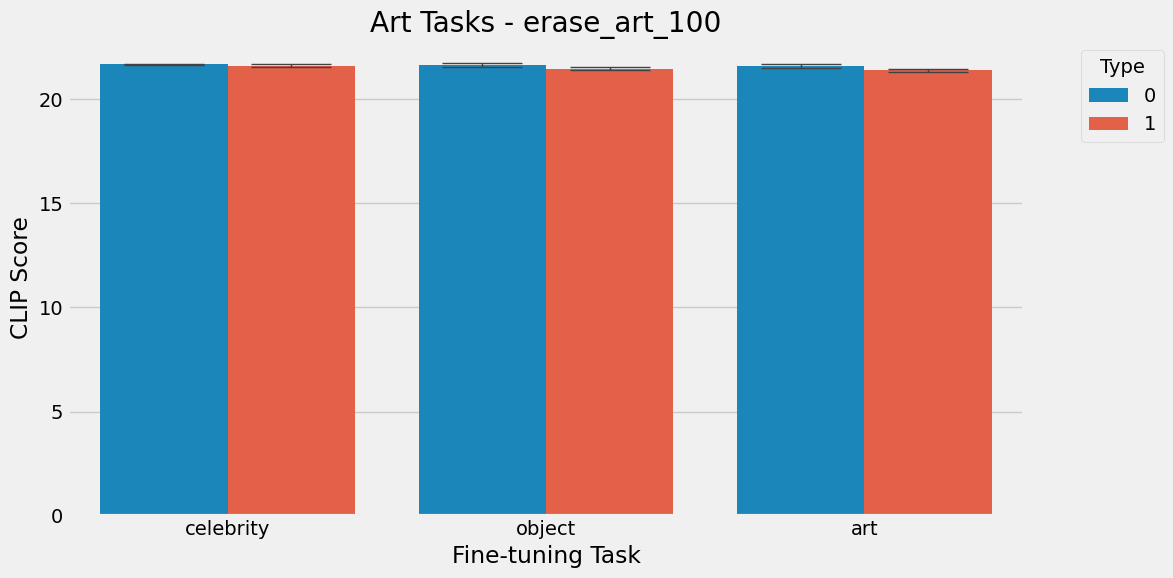

Figure saved as 'figures/in_vs_out_domain/art_in_vs_out_domain.png'


/tmp/ipykernel_4031762/4022092061.py:36: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_4031762/4022092061.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['finetune_task'].unique())


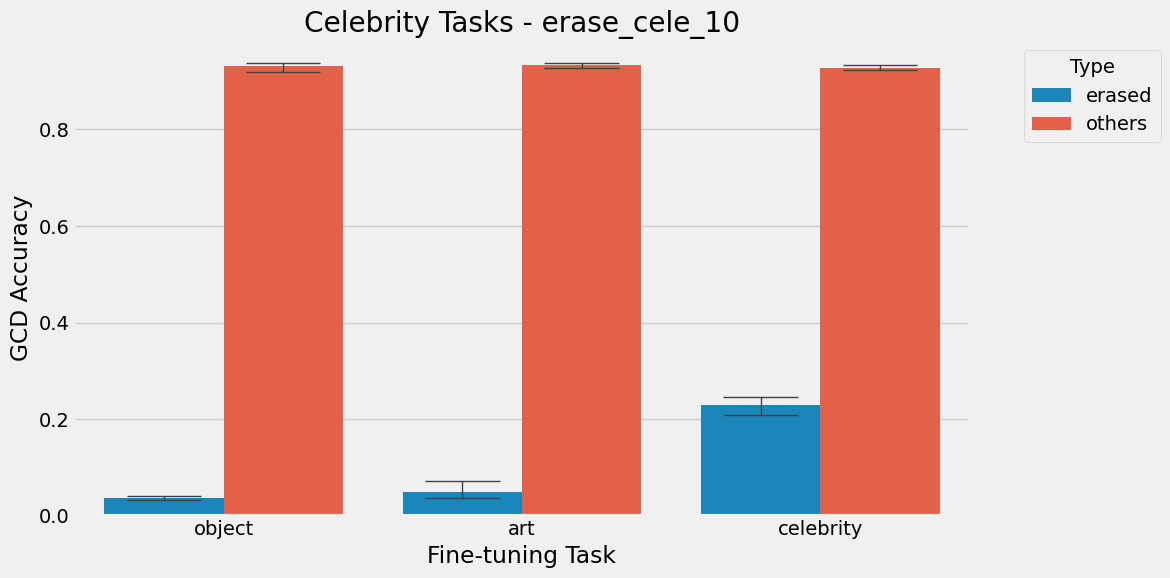

Figure saved as 'figures/in_vs_out_domain/celebrity_in_vs_out_domain.png'


In [55]:
change = 'In vs Out of Domain'
change_str = 'baseline'

for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]

    grouped = df_fig.groupby(['finetune_task', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)


    fig, ax = plt.subplots(figsize=(12, 6))

    ax.set_xlabel('Fine-tuning Task')
    

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)
    ax.set_xticklabels(df_fig['finetune_task'].unique())

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/warmup' directory if it doesn't exist
    import os
    os.makedirs('figures/in_vs_out_domain', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/in_vs_out_domain/{task}_in_vs_out_domain.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/in_vs_out_domain/{task}_in_vs_out_domain.png'")